# Transport Analytics Notebook

This notebook is the supporting walkthrough for the final report. It follows the PostgreSQL-backed project flow, reads the generated result tables under `report/results/`, and stays intentionally narrower than the paper so it does not become a competing narrative.


## Objective

The project compares Paris and NYC transport demand with four final methods:

- temporal profiling
- lag-based forecasting
- anomaly detection
- contributor and city-structure comparison


In [1]:
import subprocess
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
_ = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements.txt')],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)


In [2]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RESULTS = ROOT / 'report' / 'results'
FIGURES = ROOT / 'report' / 'figures'
import sys
sys.path.insert(0, str(ROOT / 'src'))
plt.style.use('seaborn-v0_8-whitegrid')
RESULTS


PosixPath('/home/eversince/Desktop/Coding/Github/S2/Big_data_project/report/results')

## Data and architecture

The project keeps uploaded transport data in PostgreSQL and exposes reporting-ready views through the `transport` schema. The official execution path is PostgreSQL-first: `scripts/run_stage_workflow.py` reads those views, generates the analytical outputs, and writes the derived CSV files consumed here.

The notebook does not rerun the full workflow by default. Its role is to inspect the generated outputs, mirror the report structure at a high level, and keep the interpretation consistent with the paper.


In [3]:
summary = json.loads((RESULTS / 'analysis_summary.json').read_text())
forecast_overall = pd.read_csv(RESULTS / 'forecast_metrics_overall.csv')
forecast_by_city = pd.read_csv(RESULTS / 'forecast_metrics_by_city.csv')
anomaly_rates = pd.read_csv(RESULTS / 'anomaly_rates.csv')
city_structure = pd.read_csv(RESULTS / 'city_structure_summary.csv')
top_contributors = pd.read_csv(RESULTS / 'top_contributors.csv')
yearly_totals = pd.read_csv(RESULTS / 'temporal_yearly_totals.csv')
monthly_profile = pd.read_csv(RESULTS / 'temporal_monthly_profile.csv')
forecast_predictions = pd.read_csv(RESULTS / 'forecast_predictions.csv', parse_dates=['date'])
anomaly_flags = pd.read_csv(RESULTS / 'anomaly_flags.csv', parse_dates=['date'])
summary


{'station_fact_rows': 2003,
 'daily_rows': 12696,
 'featured_rows': 12696,
 'enriched_rows': 12696,
 'stage1_selected_methods': 4}

## Methods and reported outputs

The paper focuses on four methods and this notebook follows the same order:

- temporal profiling from cleaned daily demand aggregates
- lag-based forecasting from the reporting-ready daily series
- anomaly detection from the same daily baseline
- contributor and city-structure analysis from cleaned station and regional summaries

## Results

### Temporal patterns


In [4]:
yearly_totals


,city,source,metric_type,year,total_value
0,NYC,mta_station_daily,ridership,2020,6.433108e+08
1,NYC,mta_station_daily,ridership,2021,7.639145e+08
2,NYC,mta_station_daily,ridership,2022,1.020580e+09
3,NYC,mta_station_daily,ridership,2023,1.163347e+09
4,NYC,mta_station_daily,ridership,2024,1.211513e+09
5,Paris,idfm_station_daily,validations,2015,1.494044e+09
6,Paris,idfm_station_daily,validations,2016,1.590142e+09
7,Paris,idfm_station_daily,validations,2017,1.672253e+09
8,Paris,idfm_station_daily,validations,2018,1.675803e+09
9,Paris,idfm_station_daily,validations,2019,1.695722e+09


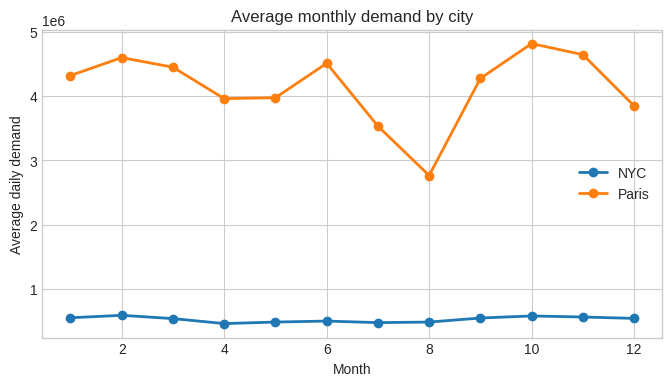

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for city, group in monthly_profile.groupby('city'):
    avg = group.groupby('month', as_index=False)['avg_value'].mean()
    ax.plot(avg['month'], avg['avg_value'], marker='o', linewidth=2, label=city)
ax.set_title('Average monthly demand by city')
ax.set_xlabel('Month')
ax.set_ylabel('Average daily demand')
ax.legend()
plt.show()


### Forecasting


In [6]:
forecast_overall, forecast_by_city


(  split_cutoff_date           mae           rmse      mape  train_rows  \
 0        2023-01-03  52908.847559  156343.131191  0.060221        8336   
 
    test_rows  
 0       4276  ,
     city            mae           rmse      mape    rows
 0    NYC   29401.762582   62965.166344  0.058619  3640.0
 1  Paris  187446.252148  376360.898706  0.069392   636.0)

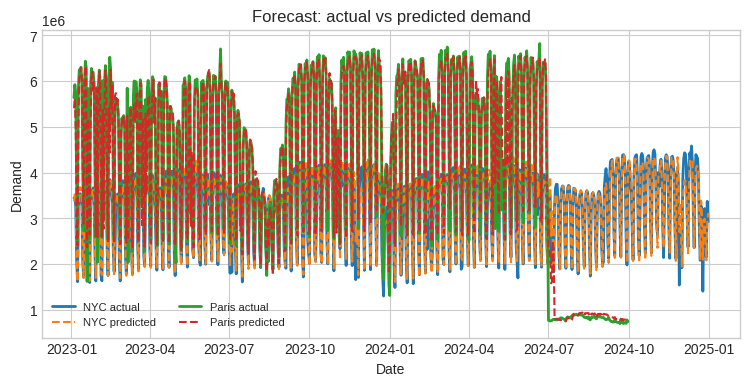

In [7]:
plot_df = forecast_predictions.groupby(['date', 'city'], as_index=False)[['value', 'prediction']].sum().sort_values('date')
fig, ax = plt.subplots(figsize=(9, 4))
for city, group in plot_df.groupby('city'):
    ax.plot(group['date'], group['value'], linewidth=2, label=f'{city} actual')
    ax.plot(group['date'], group['prediction'], linestyle='--', label=f'{city} predicted')
ax.set_title('Forecast: actual vs predicted demand')
ax.set_xlabel('Date')
ax.set_ylabel('Demand')
ax.legend(ncol=2, fontsize=8)
plt.show()


### Anomaly detection


In [8]:
anomaly_rates


,city,source,anomaly_rate
0,NYC,mta_station_daily,0.007334
1,Paris,idfm_station_daily,0.089582


In [9]:
anomaly_flags[['date', 'city', 'region', 'value', 'zscore_30']].head(15)


,date,city,region,value,zscore_30
0,2020-05-11,Paris,Ile-de-France,843231.0,4.481902
1,2020-05-12,Paris,Ile-de-France,987643.0,3.779760
2,2020-05-13,Paris,Ile-de-France,1002397.0,3.053505
3,2021-08-22,NYC,Manhattan,379225.0,-2.937101
4,2021-08-22,NYC,Brooklyn,176563.0,-2.882054
5,2024-07-01,Paris,Ile-de-France,771710.0,-2.855346
6,2015-03-21,Paris,Ile-de-France,62865.0,-2.736618
7,2020-05-14,Paris,Ile-de-France,1034047.0,2.659741
8,2021-08-22,NYC,Queens,121151.0,-2.614095
9,2024-07-02,Paris,Ile-de-France,769554.0,-2.566120


### Contributors and city structure


In [10]:
city_structure


,city,avg_daily_value,median_daily_value,std_daily_value,coeff_variation,weekend_weekday_ratio,peak_month,row_count
0,NYC,2.628716e+06,2564067.0,1.146997e+06,0.436334,0.584383,2.0,1827.0
1,Paris,4.127083e+06,4352888.0,1.760599e+06,0.426596,0.511900,10.0,3561.0


In [11]:
top_contributors.head(12)


,city,source,location_name,total_value
0,Paris,idfm_station_daily,SAINT-LAZARE,432319111.0
1,Paris,idfm_station_daily,LA DEFENSE-GRANDE ARCHE,325308024.0
2,Paris,idfm_station_daily,GARE DE LYON,291642740.0
3,Paris,idfm_station_daily,GARE DU NORD,247209096.0
4,Paris,idfm_station_daily,MONTPARNASSE,246781733.0
5,Paris,idfm_station_daily,GARE DE L'EST,227129241.0
6,NYC,mta_station_daily,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",168202157.0
7,Paris,idfm_station_daily,CHATELET-LES HALLES,165508076.0
8,Paris,idfm_station_daily,CHATELET,140154050.0
9,NYC,mta_station_daily,"Grand Central-42 St (S,4,5,6,7)",115353629.0


## Discussion and limitations

- Paris carries the higher average daily volume in the cleaned reporting scope, while NYC shows a stronger relative weekday-weekend contrast.
- The current lag-based forecasting baseline performs better on NYC than on Paris, which is consistent with the lower NYC error metrics in `forecast_metrics_by_city.csv`.
- Paris also shows the higher anomaly rate in the generated outputs, so the anomaly tables should be read as a screening layer for disruption periods rather than a causal explanation.
